# Exploring the NWP reforecasts (GEFS 2000 to 2025)

This notebook analyses the reanalysed weather forecasts before integrating them as
features into the ML pricing models.

**Questions we want to answer:**
1. What is the seasonal structure of the forecast uncertainty σ_f?
2. Are the uncertainty clusters consistent across cities?
3. What is the informative value of the J+1..J+7 forecasts?
    → correlation between X_f^{J+h} and the realized X_{t+h}
4. Are the forecasts biased? (bias by horizon and season)
5. Are the dj7 revisions informative about future volatility?


We will finally won't use these features in ML models but we will try to use it by coupling it with natgas volatility (folder `3_Couplage`)

In [1]:
import sys; sys.path.append("../../src")
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import DATA_DIR, CLEANED_DIR, TRAIN_END, BASE_TEMP
from data_cleaning import clean_data
from feature_engineering import compute_doy_stats
from nwp import load_nwp_all_years, build_nwp_features
from ou_simulation import load_ou_params

plt.rcParams.update({
    "font.family": "serif", "font.size": 10, "axes.titlesize": 11,
    "axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
})
FOCUS = "chicago"
NWP_DIR = DATA_DIR / "NOAA_forecast"


We first build the NWP features from the raw NOAA data.

In [2]:
# Realized data (OU dataset) + GEFS forecasts + NWP features via src/nwp.py
df = clean_data(pd.read_csv(f"{CLEANED_DIR}/{FOCUS}_ou_dataset.csv",
                            index_col=0, parse_dates=True), verbose=False)
doy_stats = compute_doy_stats(df[df.index <= TRAIN_END], temp_col="T")

raw_nwp = load_nwp_all_years(str(NWP_DIR), cities=[FOCUS])
feats = build_nwp_features(df_nwp=raw_nwp, doy_stats_map={FOCUS: doy_stats}, city=FOCUS)

# joined table: forecast (issued at t) x realized, raw "{city}_jh" -> "jh"
M = feats.join(df[["T", "theta", "X_t", "epsilon_t"]], how="inner")
M = M.join(raw_nwp.rename(columns=lambda c: c.replace(f"{FOCUS}_", "")), how="left")
print(f"{len(M):,} forecast days ({M.index.min().date()} → {M.index.max().date()})")
feats.tail(3).round(2)


✓ NWP chargé : 9000 jours (2000-01-01 → 2025-05-14)
  Colonnes (7) : ['chicago_j1', 'chicago_j2', 'chicago_j3', 'chicago_j4', 'chicago_j5', 'chicago_j6'] ...


8,988 forecast days (2000-01-01 → 2025-05-14)


,Xf_j1,Xf_j2,Xf_j3,Xf_j4,Xf_j5,Xf_j6,Xf_j7,sigma_f,f_mean,f_trend,df_j1_abs,df_j2_abs,df_j3_abs,df_j4_abs,df_j5_abs,df_j6_abs,df_j7_abs,df_j7_signed,hdd_implied
date,,,,,,,,,,,,,,,,,,,
2025-05-12,-0.34,-0.67,2.39,4.08,-0.42,-7.58,-7.53,4.20,13.49,-5.27,0.57,0.12,2.53,2.02,3.57,6.52,5.71,-5.71,32.81
2025-05-13,-1.81,1.34,3.62,-0.44,-5.17,-8.04,-6.85,4.02,12.72,-3.97,0.60,2.18,1.55,4.82,3.98,0.37,0.70,0.70,37.69
2025-05-14,1.40,4.35,0.15,-5.51,-7.03,-5.63,-2.44,3.91,13.30,-2.64,3.38,3.33,3.77,4.30,1.77,2.43,4.71,4.71,34.41


The exogenous variables added to each city, all available at $t$ with no
*data leakage* risk:

### Glossary of exogenous forecast variables

| Variable | Definition / Formula | Available at $t$ |
| :--- | :--- | :---: |
| **`j1`..`j7`** | Forecast mean temperature for $t+1$ .. $t+7$ (°C) | ✓ |
| **`Xf_j1`..`Xf_j7`** | $j_h - \theta(t+h)$: forecast deviation from the climatological normal of $t+h$ | ✓ |
| **`sigma_f`** | $\text{std}(j1..j7)$: cross-horizon dispersion, a proxy for weather uncertainty over the coming week | ✓ |
| **`f_mean`** | $\text{mean}(j1..j7)$: expected average temperature over the next 7 days | ✓ |
| **`f_trend`** | $j7 - j1$: warming/cooling trend over the $J+1 \rightarrow J+7$ window | ✓ |
| **`dj1_abs`..`dj7_abs`** | $\vert j_{h,t} - j_{h,t-1} \vert$: NWP turbulence at horizon $h$ (`dj7_abs` is the GARCH-X E2 signal) | ✓ |
| **`dj7_signed`** | $j7_t - j7_{t-1}$: signed version of the $J+7$ turbulence (direction of the change) | ✓ |
| **`hdd_implied`** | $\sum_{h=1}^{7}\max(18 - j_h, 0)$: forecast-implied HDD over the coming week | ✓ |

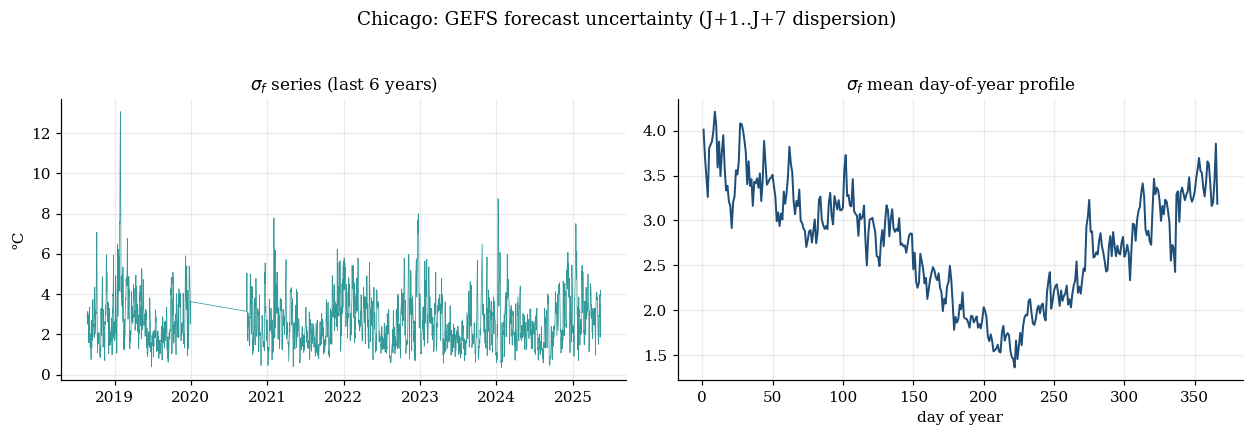

In [3]:
# Q1: seasonal structure of the forecast uncertainty sigma_f
prof = M.groupby(M.index.dayofyear)["sigma_f"].mean()
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
axes[0].plot(M.index[-365*6:], M["sigma_f"].iloc[-365*6:], lw=0.5, color="teal", alpha=0.8)
axes[0].set_title("$\\sigma_f$ series (last 6 years)"); axes[0].set_ylabel("°C")
axes[1].plot(prof.index, prof.values, lw=1.3, color="#1f4e79")
axes[1].set_title("$\\sigma_f$ mean day-of-year profile")
axes[1].set_xlabel("day of year")
fig.suptitle(f"{FOCUS.title()}: GEFS forecast uncertainty (J+1..J+7 dispersion)", y=1.03)
fig.tight_layout()


Forecast dispersion is clearly much higher in winter and low in summer. Forecasts are
more uncertain in winter, with higher day-to-day variability.

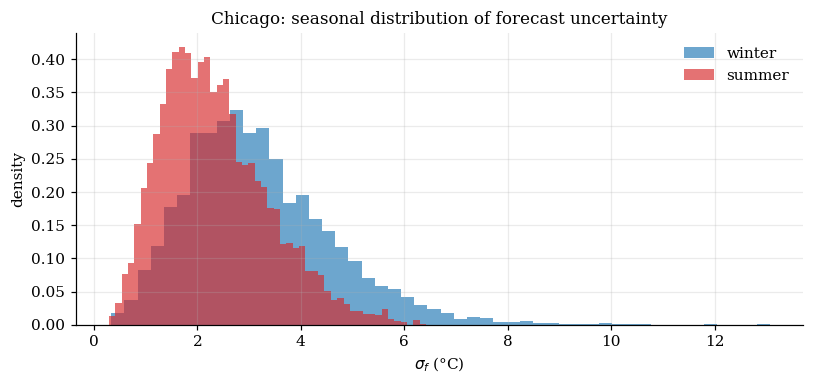

In [4]:
# Seasonal distribution of sigma_f
w = M.index.month.isin([10, 11, 12, 1, 2, 3])
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.hist(M.loc[w, "sigma_f"], bins=50, density=True, alpha=0.65, color="#1f77b4", label="winter")
ax.hist(M.loc[~w, "sigma_f"], bins=50, density=True, alpha=0.65, color="#d62728", label="summer")
ax.set_xlabel("$\\sigma_f$ (°C)"); ax.set_ylabel("density")
ax.set_title(f"{FOCUS.title()}: seasonal distribution of forecast uncertainty")
ax.legend(frameon=False)
fig.tight_layout()


As expected, winter variances are more spread out than summer ones. Winter days are
less stable from one day to the next.

horizon,J+1,J+2,J+3,J+4,J+5,J+6,J+7
corr,0.863,0.849,0.83,0.803,0.758,0.703,0.635


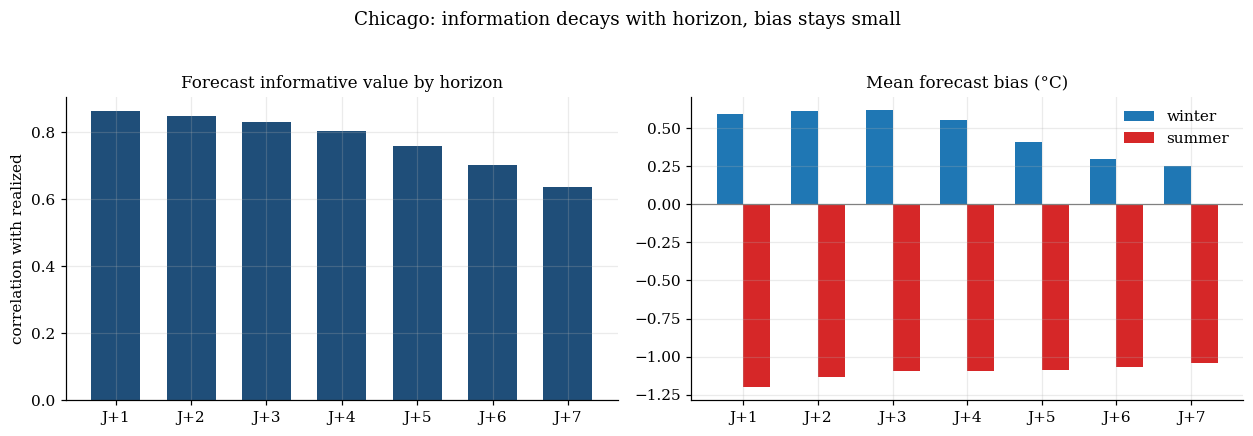

In [5]:
# Q3: informative value, corr( Xf_{J+h} issued at t , realized X_{t+h} ), h = 1..7
rows = []
for h in range(1, 8):
    rows.append({"horizon": f"J+{h}",
                 "corr": M[f"Xf_j{h}"].corr(M["X_t"].shift(-h))})
corr_h = pd.DataFrame(rows).set_index("horizon")

# Q4: bias by horizon and season, mean( j_h - T_{t+h} )
bias = {}
for h in range(1, 8):
    e = M[f"j{h}"] - M["T"].shift(-h)
    bias[f"J+{h}"] = {"winter": e[w].mean(), "summer": e[~w].mean()}
bias = pd.DataFrame(bias).T

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
axes[0].bar(corr_h.index, corr_h["corr"], color="#1f4e79", width=0.65)
axes[0].set_title("Forecast informative value by horizon")
axes[0].set_ylabel("correlation with realized")
x = np.arange(7)
axes[1].bar(x - 0.18, bias["winter"], 0.36, label="winter", color="#1f77b4")
axes[1].bar(x + 0.18, bias["summer"], 0.36, label="summer", color="#d62728")
axes[1].set_xticks(x, bias.index); axes[1].axhline(0, color="grey", lw=0.8)
axes[1].set_title("Mean forecast bias (°C)"); axes[1].legend(frameon=False)
fig.suptitle(f"{FOCUS.title()}: information decays with horizon, bias stays small", y=1.03)
fig.tight_layout()
display(corr_h.round(3).T)


The forecast correlation with the realized residual decays as the horizon grows, and the mean bias stays small in both winter and summer at every horizon.

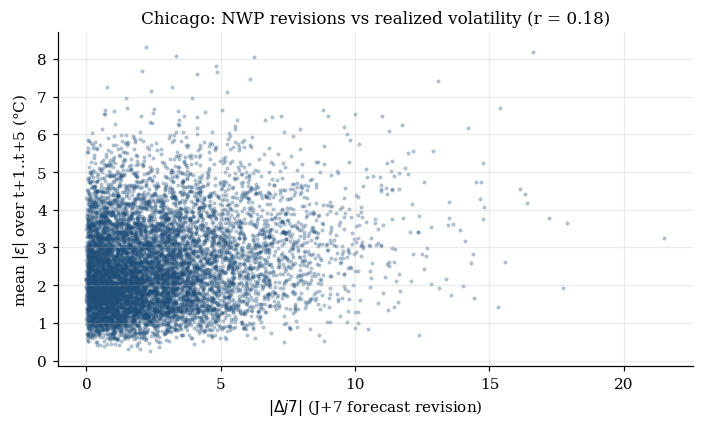

In [6]:
# Q5: do |dj7| revisions anticipate realized volatility?
# (this is the phi channel of the GARCH-X E2: forecast surprise -> gas vol)
rev = M["df_j7_abs"]
vol_future = M["epsilon_t"].abs().shift(-1).rolling(5).mean().shift(-4)  # |eps| over t+1..t+5
r = rev.corr(vol_future)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.scatter(rev, vol_future, s=3, alpha=0.25, color="#1f4e79")
ax.set_xlabel("$|\\Delta j7|$ (J+7 forecast revision)")
ax.set_ylabel("mean $|\\varepsilon|$ over t+1..t+5 (°C)")
ax.set_title(f"{FOCUS.title()}: NWP revisions vs realized volatility (r = {r:.2f})")
fig.tight_layout()


Forecasts degrade over the horizon, with increasing dispersion. Ideally, if a desk could
dynamically adjust its positions based on these forecasts, it would maximize profits by
re-hedging daily on the next-day forecast. Let us measure the impact of using these forecasts
on the monthly costs of a hypothetical desk buying HDD contracts, where every unhedged HDD
error costs a fixed amount, here $2{,}500\$$ per HDD (illustrative figure).

Mean annual cost (k$): {'Climatology (doy)': 2899, 'NWP J+1': 1314, 'OU conditional': 1747}


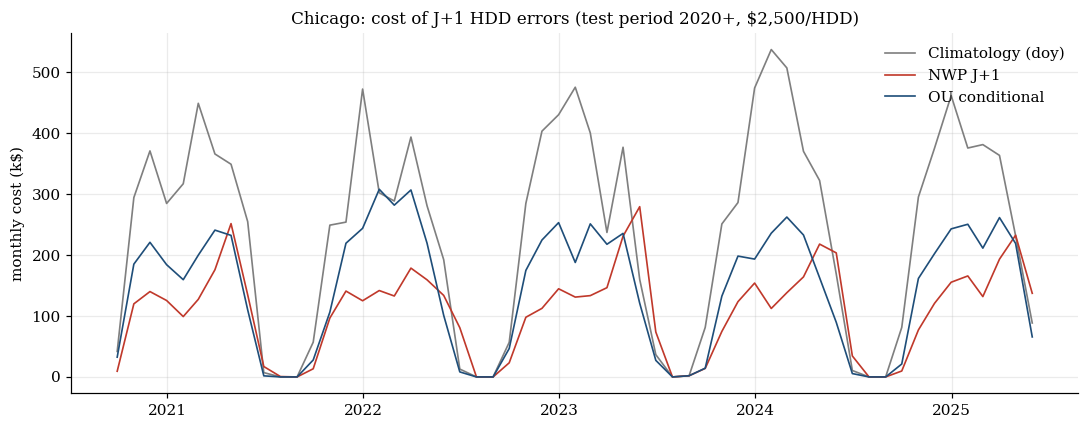

In [7]:
# Three predictors of TOMORROW's HDD, cost = $2,500 per HDD of error
phi = float(load_ou_params(FOCUS)["phi"])
COST = 2500
T_next = M["T"].shift(-1)
hdd_real_d = np.maximum(BASE_TEMP - T_next, 0)
preds = {
    "Climatology (doy)": np.maximum(
        BASE_TEMP - doy_stats["doy_mean"].reindex(
            (M.index + pd.Timedelta(days=1)).strftime("%m-%d")).to_numpy(), 0),
    "NWP J+1":           np.maximum(BASE_TEMP - M["j1"], 0),
    "OU conditional":    np.maximum(
        BASE_TEMP - (M["theta"].shift(-1) + phi * M["X_t"]), 0),
}
costs = pd.DataFrame({name: COST * np.abs(p - hdd_real_d) for name, p in preds.items()},
                     index=M.index).dropna()
monthly = costs.loc["2020":].resample("ME").sum() / 1e3

fig, ax = plt.subplots(figsize=(10, 4))
for name, col in zip(costs.columns, ["#7f7f7f", "#c0392b", "#1f4e79"]):
    ax.plot(monthly.index, monthly[name], lw=1.1, label=name, color=col)
ax.set_ylabel("monthly cost (k$)")
ax.set_title(f"{FOCUS.title()}: cost of J+1 HDD errors (test period 2020+, $2,500/HDD)")
ax.legend(frameon=False)
fig.tight_layout()
print("Mean annual cost (k$):",
      {k: round(v) for k, v in (monthly.mean() * 12).items()})


The naive climatologist approach (same-day historical mean) clearly underperforms the
NWP forecasts. Note however that we took the most favourable setup for the latter: the
forecast is issued just before the end of the day and the desk re-hedges daily on tomorrow's
forecast. In reality, at contract inception the desk only has the J+1..J+7 forecasts and then
nothing, so this is an upper bound on what the forecasts can deliver. Conversely, the OU
model performs distinctly better than the alternatives.

This raises the question: can an ML model trained on historical data outperform both the
mathematical models and the forecasts? See `5_ML_Evaluation&MC.ipynb`.

---
**Project status.** The NWP features (V2 block) are abandoned: Forecast information already has an **out-of-sample validated edge** elsewhere in the project: the E2 gas GARCH-X uses the $|\Delta \text{forecast}_{J+7}|$ surprise (see folder `3_Couplage`). The exploration here feeds that result directly.